[Import Packages & Dataset](#Import-Packages-&-Dataset)\
[Numerical Variables](#Numerical-Variables)\
[Numerical - Correlation](#Numerical---Correlation)\
[Categorical Variables](#Categorical-Variables)\
[Categorical - Correlation](#Categorical---Correlation)\
[Categorical - Plots](#Categorical---Plots)

# Import Packages & Dataset

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import matplotlib.pyplot as plt
from scipy.stats import shapiro
from scipy.stats import mannwhitneyu
from scipy.stats import ttest_ind



ModuleNotFoundError: No module named 'pandas'

In [76]:
insurance_claims = pd.read_csv('insurance_claims.csv', sep=',')
df = insurance_claims.copy()

print(df.shape)

pd.set_option('display.max_columns', None)
df.head(5)

(1000, 40)


,months_as_customer,age,policy_number,policy_bind_date,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,insured_sex,insured_education_level,insured_occupation,insured_hobbies,insured_relationship,capital-gains,capital-loss,incident_date,incident_type,collision_type,incident_severity,authorities_contacted,incident_state,incident_city,incident_location,incident_hour_of_the_day,number_of_vehicles_involved,property_damage,bodily_injuries,witnesses,police_report_available,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_make,auto_model,auto_year,fraud_reported,_c39
0,328,48,521585,2014-10-17,OH,250/500,1000,1406.91,0,466132,MALE,MD,craft-repair,sleeping,husband,53300,0,2015-01-25,Single Vehicle Collision,Side Collision,Major Damage,Police,SC,Columbus,9935 4th Drive,5,1,YES,1,2,YES,71610,6510,13020,52080,Saab,92x,2004,Y,NaN
1,228,42,342868,2006-06-27,IN,250/500,2000,1197.22,5000000,468176,MALE,MD,machine-op-inspct,reading,other-relative,0,0,2015-01-21,Vehicle Theft,?,Minor Damage,Police,VA,Riverwood,6608 MLK Hwy,8,1,?,0,0,?,5070,780,780,3510,Mercedes,E400,2007,Y,NaN
2,134,29,687698,2000-09-06,OH,100/300,2000,1413.14,5000000,430632,FEMALE,PhD,sales,board-games,own-child,35100,0,2015-02-22,Multi-vehicle Collision,Rear Collision,Minor Damage,Police,NY,Columbus,7121 Francis Lane,7,3,NO,2,3,NO,34650,7700,3850,23100,Dodge,RAM,2007,N,NaN
3,256,41,227811,1990-05-25,IL,250/500,2000,1415.74,6000000,608117,FEMALE,PhD,armed-forces,board-games,unmarried,48900,-62400,2015-01-10,Single Vehicle Collision,Front Collision,Major Damage,Police,OH,Arlington,6956 Maple Drive,5,1,?,1,2,NO,63400,6340,6340,50720,Chevrolet,Tahoe,2014,Y,NaN
4,228,44,367455,2014-06-06,IL,500/1000,1000,1583.91,6000000,610706,MALE,Associate,sales,board-games,unmarried,66000,-46000,2015-02-17,Vehicle Theft,?,Minor Damage,NaN,NY,Arlington,3041 3rd Ave,20,1,NO,0,1,NO,6500,1300,650,4550,Accura,RSX,2009,N,NaN


In [77]:
# Check info
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 40 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   months_as_customer           1000 non-null   int64  
 1   age                          1000 non-null   int64  
 2   policy_number                1000 non-null   int64  
 3   policy_bind_date             1000 non-null   str    
 4   policy_state                 1000 non-null   str    
 5   policy_csl                   1000 non-null   str    
 6   policy_deductable            1000 non-null   int64  
 7   policy_annual_premium        1000 non-null   float64
 8   umbrella_limit               1000 non-null   int64  
 9   insured_zip                  1000 non-null   int64  
 10  insured_sex                  1000 non-null   str    
 11  insured_education_level      1000 non-null   str    
 12  insured_occupation           1000 non-null   str    
 13  insured_hobbies              1

In [78]:
#check missing value
print(df.columns[df.isnull().any()])
print('pourcentage of missing value for col authorithies contracted', (df['authorities_contacted'].isnull().sum()*100)/len(df['authorities_contacted']), '%' )



Index(['authorities_contacted', '_c39'], dtype='str')
pourcentage of missing value for col authorithies contracted 9.1 %


column _c38: no data   
column authorities_contacted: 9.1% of missing values

In [79]:
#drop df
df = df.drop(columns='_c39')

In [80]:
# change col date to datetime
df["policy_bind_date"] = pd.to_datetime(df["policy_bind_date"])
df["incident_date"] = pd.to_datetime(df["incident_date"])

In [81]:
#Check target
df['fraud_reported'].value_counts(normalize = True, dropna=False)

fraud_reported
N    0.753
Y    0.247
Name: proportion, dtype: float64

No missing value for target    
Non Fraude : 75% of dataset   
Fraude : 25 % of dataset

# Numerical Variables

In [82]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
print(num_cols)
len(num_cols)


['months_as_customer', 'age', 'policy_number', 'policy_deductable', 'policy_annual_premium', 'umbrella_limit', 'insured_zip', 'capital-gains', 'capital-loss', 'incident_hour_of_the_day', 'number_of_vehicles_involved', 'bodily_injuries', 'witnesses', 'total_claim_amount', 'injury_claim', 'property_claim', 'vehicle_claim', 'auto_year']


18

**1 - Distribution des variables numérique selon la variable cible**

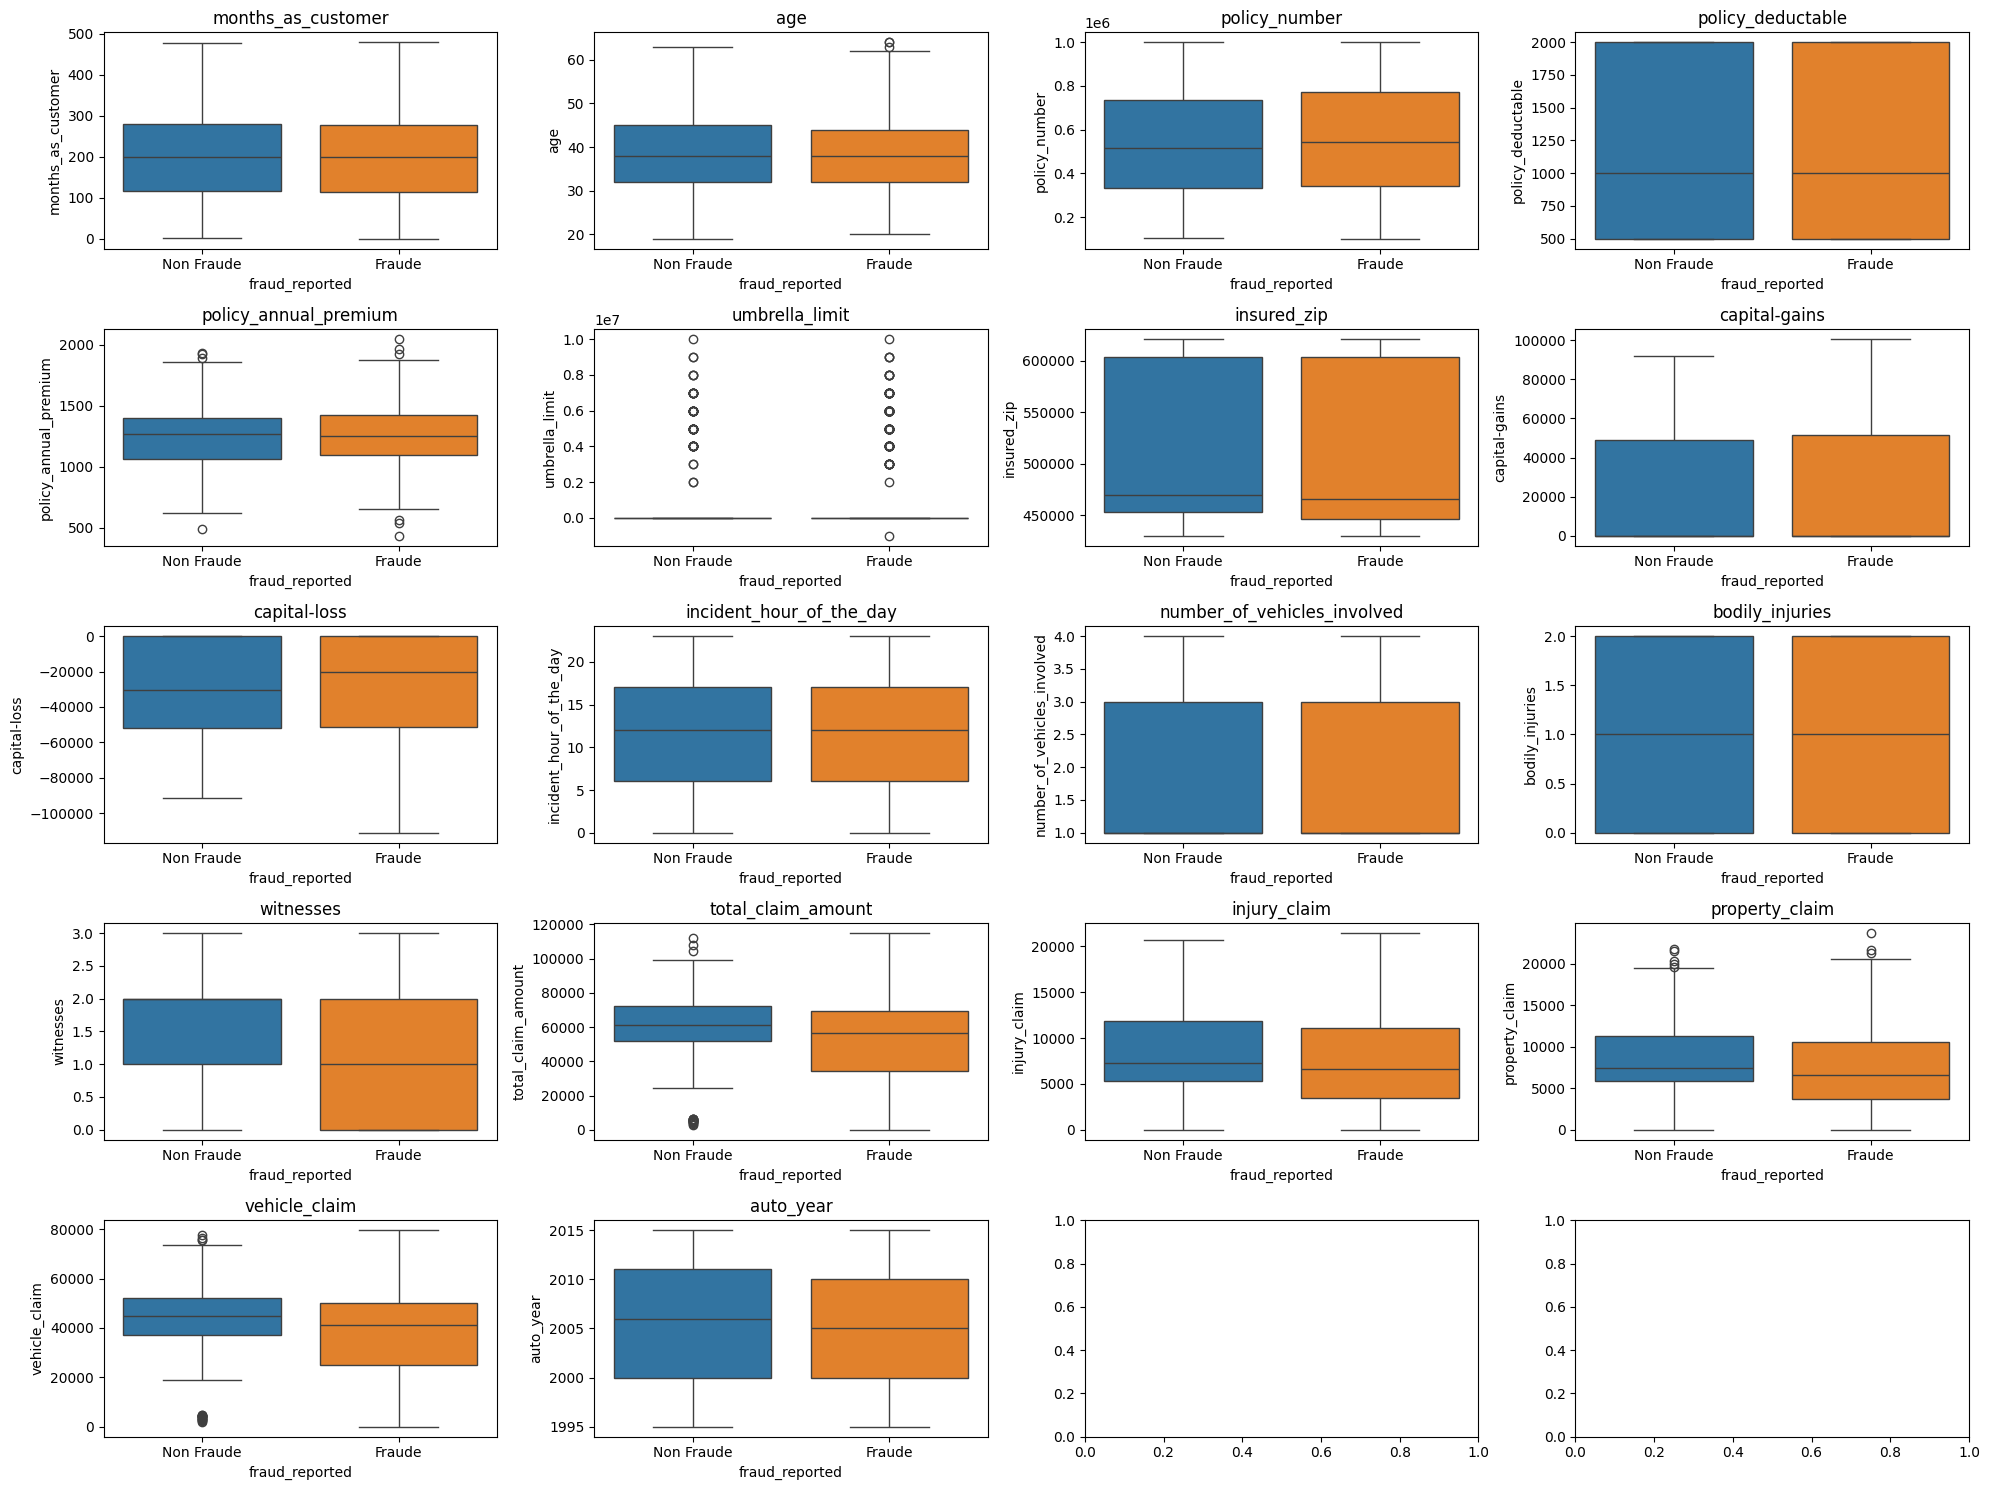

In [83]:
#illustration Variable numérique

fig, axes = plt.subplots(5,4,figsize=(20,15))
axes = axes.flatten()
for i,col in enumerate(num_cols):
    sns.boxplot(x='fraud_reported', y=col, data=df, ax = axes[i], hue = 'fraud_reported', legend= '')
    axes[i].set_title(col)
    axes[i].set_xticks([0,1], ['Non Fraude', 'Fraude'])  
plt.tight_layout()
plt.show()  


**List of columns showing a different distribution between fraud and non-fraud (visually):**   
- policy number → numéro d’assurance  
- capital loss → perte en capital   
- witnesses → témoins  
- total claim amount → montant total de la réclamation   
- injury claim → réclamation pour dommages corporels   
- property insurance_claims → réclamations d’assurance habitation / dommages matériels   
- Vehicle insurance_claims → réclamations d’assurance automobile   
- auto year → année du véhicule   

**Significatif?**  
1 - Donnée normale ?

***Le test de Shapiro-Wilk permet de vérifier si un échantillon suit une distribution normale.
***

p > 0.05 → pas de violation de normalité.

p ≤ 0.05 → distribution non normale.

In [84]:

for col in num_cols:
    stat1, p1 = shapiro(df[df['fraud_reported']=='Y'][col])
    stat2, p2 = shapiro(df[df['fraud_reported']=='N'][col])
    if p1>0.05 or p1>0.05:
        print(f'{col}: p_nonfraude={p1:.3f}, p_fraude={p2:.3f}')

policy_annual_premium: p_nonfraude=0.513, p_fraude=0.999


**Seule policy annual premium suit la loie normale**



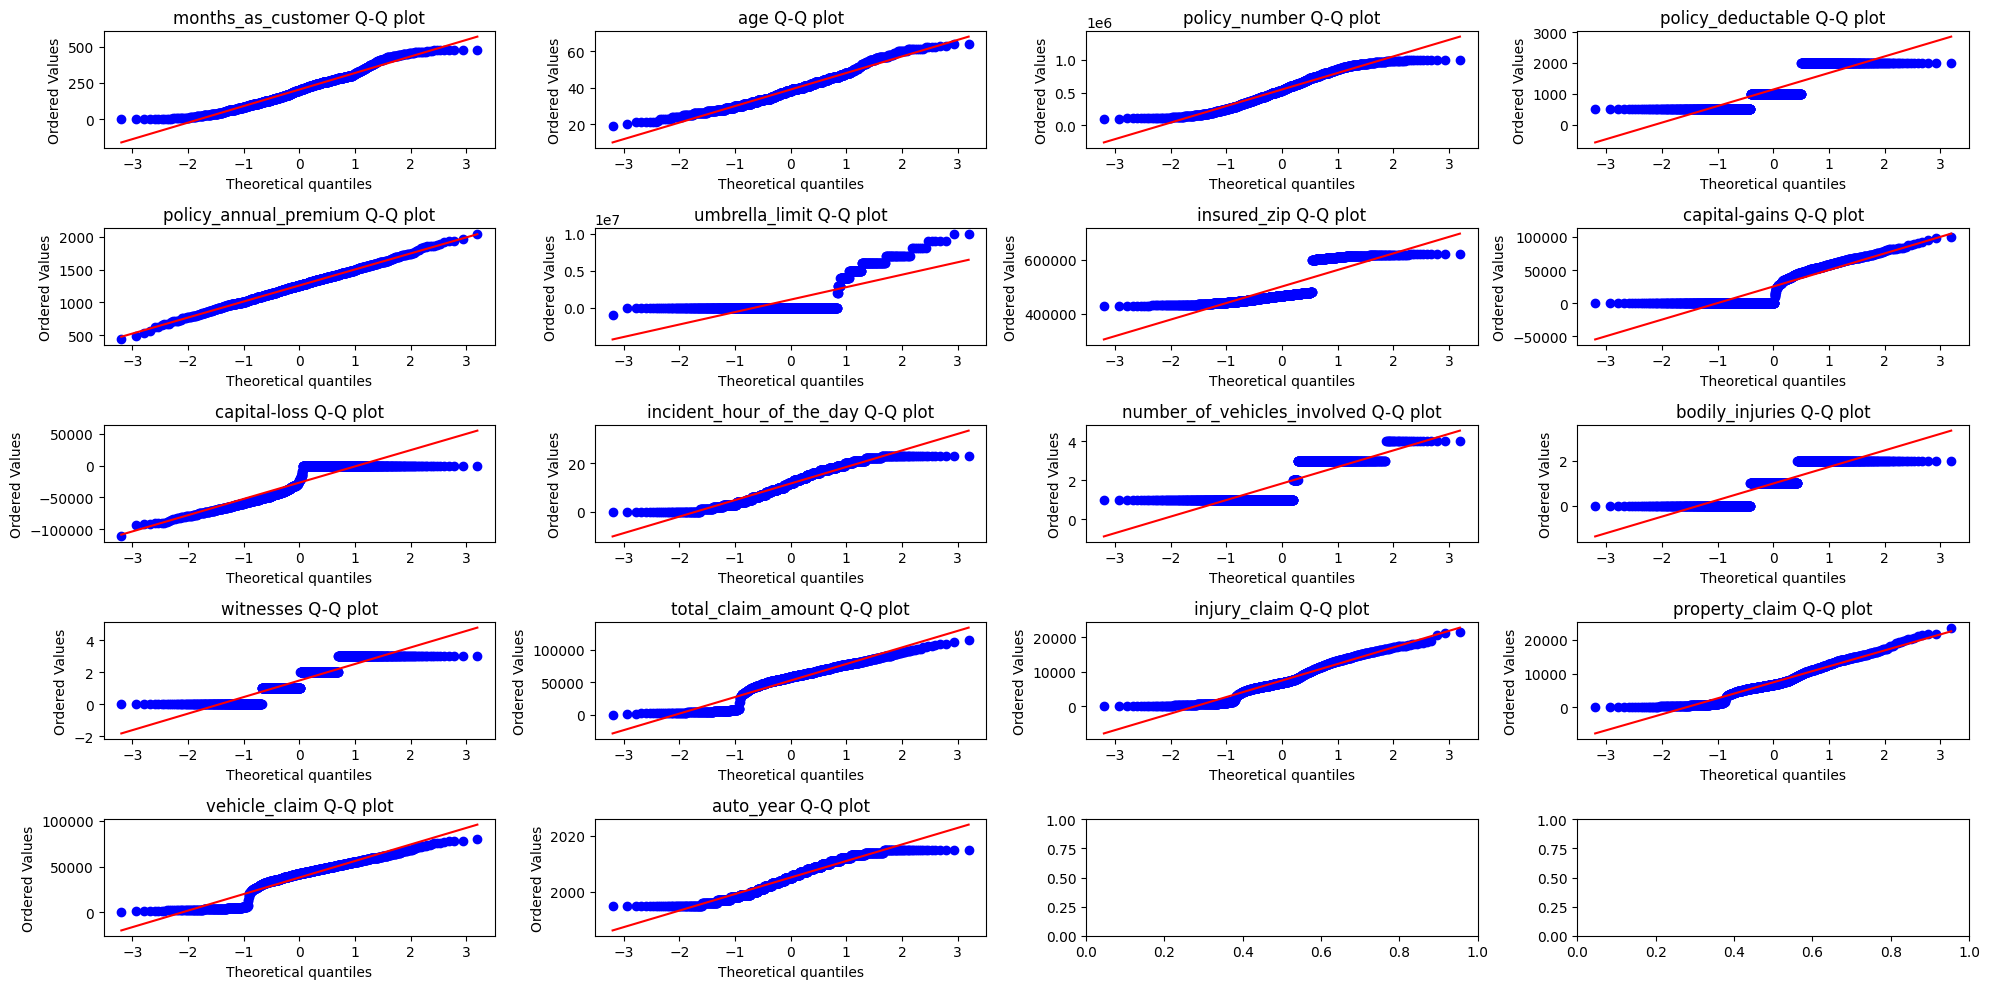

In [85]:
#Verification
#!pip install scipy

fig, axes = plt.subplots(5,4,figsize=(20,10))
axes = axes.flatten()
for i,col in enumerate(num_cols):
    stats.probplot(df[col], dist="norm", plot=axes[i])
    axes[i].set_title(col + ' Q-Q plot')

plt.tight_layout()
plt.show()



Comme ces variables ne suivent pas la loie normale,  
on va utiliser le test de Mann witney U test  
**==>Test de différence de moyenne entre Fraude et non Fraude**

In [86]:

for col in num_cols:
    group1 = df[df['fraud_reported']=='N'][col]
    group2 = df[df['fraud_reported']=='Y'][col]
    stat, p = mannwhitneyu(group1, group2, alternative='two-sided')
    if p < 0.05:
        print(f'{col}: p-value={p:.3f}')

total_claim_amount: p-value=0.000
injury_claim: p-value=0.005
property_claim: p-value=0.000
vehicle_claim: p-value=0.000


Pour la variable qui suit la distribution normale:  
    policy annual premium
    
**==> Test de student**

In [87]:
numerical_columns = ['policy_annual_premium']
for col in numerical_columns:
    group1 = df[df['fraud_reported']=='N'][col]
    group2 = df[df['fraud_reported']=='Y'][col]
    stat, p = ttest_ind(group1, group2, nan_policy='omit')
    print(f'{col}: p-value = {p}')

policy_annual_premium: p-value = 0.6474289700892819


**==> Pas de différence significative : policy_annual_premium**


**Liste des variables pertinentes pour distinguer fraude et non‑fraude**  
- total_claim_amount 
- injury_claim
- property_claim
- vehicle_claim  
==>La figure ci‑dessous montre qu’ils sont corrélés

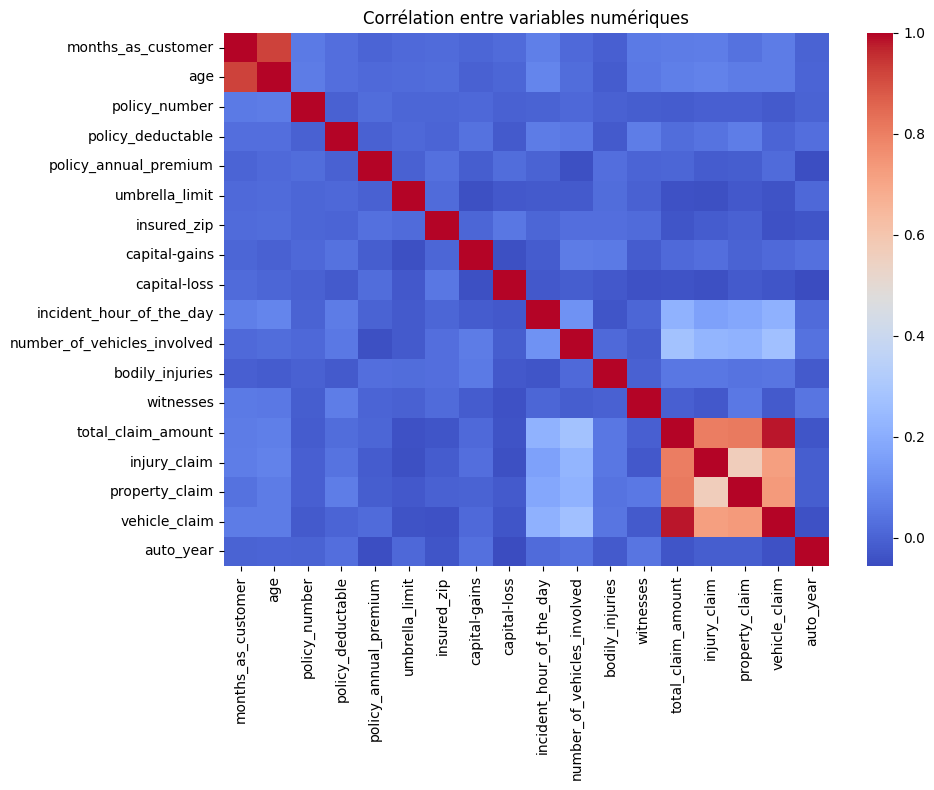

In [88]:
correlation = df[num_cols].corr()
plt.figure(figsize=(10,8))
sns.heatmap(correlation, annot = False,cbar = True, cmap = 'coolwarm')
plt.title("Corrélation entre variables numériques")
plt.tight_layout()
#plt.savefig(r'C:\Users\rvoul\Documents\formation_data_scientist\projet_fil_rouge\rapport\variable_num_correlation.png')
plt.show()

Si deux variables sont corrélées, nous pouvons prédire l'une à partir de l'autre. 
Par conséquent, si deux caractéristiques sont corrélées, le modèle n'en a besoin que d'une seule, 
la seconde n'apportant pas d'informations supplémentaires. Nous utiliserons ici la corrélation de 
Pearson.



 **2 - Valeurs aberrantes**

- age(same distribution between Fraud and non fraud)   
- policy annual premium (same distribution between Fraud and non fraud) : (= montant payé par l’assuré à la compagnie d’assurance)   
- ***total claim amount  (outlier only with non Fraud)***   
- ***property claim***   
- ***vehicle claim (outlier only with non Fraud)***  

Statistiques pour property_claim (fraude = Y) :
count      247.000000
mean      8560.121457
std       4631.741098
min          0.000000
25%       5815.000000
50%       7440.000000
75%      11300.000000
max      21810.000000
Name: property_claim, dtype: float64 

Nombre total d'outliers: 5

Exemple de table des outliers :


,months_as_customer,age,policy_number,policy_bind_date,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,insured_sex,insured_education_level,insured_occupation,insured_hobbies,insured_relationship,capital-gains,capital-loss,incident_date,incident_type,collision_type,incident_severity,authorities_contacted,incident_state,incident_city,incident_location,incident_hour_of_the_day,number_of_vehicles_involved,property_damage,bodily_injuries,witnesses,police_report_available,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_make,auto_model,auto_year,fraud_reported
106,464,61,632627,1990-10-07,OH,500/1000,1000,1125.37,0,604450,FEMALE,Associate,prof-specialty,basketball,husband,0,-56400,2015-01-13,Multi-vehicle Collision,Rear Collision,Major Damage,Police,VA,Northbend,4793 4th Ridge,6,3,?,0,2,YES,79800,6650,19950,53200,Saab,95,2000,Y
163,112,30,346940,2002-09-13,OH,500/1000,1000,1166.54,0,479852,FEMALE,Masters,prof-specialty,sleeping,not-in-family,47700,-59300,2015-01-21,Single Vehicle Collision,Front Collision,Major Damage,Fire,SC,Arlington,9316 Pine Ave,3,1,YES,2,0,NO,107900,10790,21580,75530,Dodge,Neon,1997,Y
591,43,43,528385,1997-11-07,IL,500/1000,500,1320.39,0,604861,FEMALE,Associate,armed-forces,yachting,not-in-family,0,0,2015-01-19,Single Vehicle Collision,Rear Collision,Major Damage,Ambulance,WV,Arlington,6603 Francis Hwy,16,1,?,2,1,?,79970,7270,21810,50890,Honda,CRV,1996,Y
708,46,41,315041,2010-11-02,OH,100/300,2000,998.19,0,611556,FEMALE,MD,priv-house-serv,video-games,husband,43700,-66300,2015-01-23,Multi-vehicle Collision,Rear Collision,Total Loss,Ambulance,SC,Hillsdale,5779 2nd Lane,23,3,NO,1,3,?,78600,13100,19650,45850,Dodge,RAM,2004,Y
745,258,41,605100,2001-02-15,IL,100/300,500,1042.25,0,601206,MALE,Masters,exec-managerial,reading,unmarried,0,-44400,2015-02-08,Multi-vehicle Collision,Rear Collision,Major Damage,Fire,NC,Riverwood,2905 Embaracadero Drive,0,3,NO,2,3,NO,81240,6770,20310,54160,Mercedes,C300,2008,Y


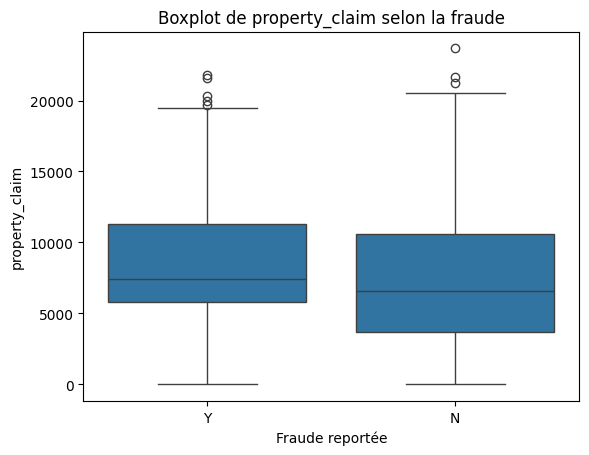

In [89]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

def check_outlier_rows(df, variable):
    """
    Affiche les statistiques descriptives pour les cas de fraude,
    détecte les outliers selon IQR et affiche un boxplot comparatif.
    """
    # Stats descriptives pour les cas de fraude (fraud_reported = 'Y')
    df_fraud = df[df['fraud_reported']=='Y']
    print(f"Statistiques pour {variable} (fraude = Y) :")
    print(df_fraud[variable].describe(), "\n")
    
    # Calcul de l'IQR
    Q1 = df_fraud[variable].quantile(0.25)
    Q3 = df_fraud[variable].quantile(0.75)
    IQR = Q3 - Q1
    
    # Bornes inférieure et supérieure
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Filtrer les outliers
    outliers = df_fraud[(df_fraud[variable] < lower_bound) | (df_fraud[variable] > upper_bound)]
    
    print(f"Nombre total d'outliers: {len(outliers)}\n")
    
    print("Exemple de table des outliers :")
    display(outliers)  # ou print(outliers) si pas sur Jupyter/Colab
    
    # Boxplot comparatif fraude vs non-fraude
    sns.boxplot(x='fraud_reported', y=variable, data=df)
    plt.title(f'Boxplot de {variable} selon la fraude')
    plt.xlabel('Fraude reportée')
    plt.ylabel(variable)
    plt.show()

# Exemple d'utilisation
check_outlier_rows(df, 'property_claim')

Statistiques pour total_claim_amount (fraude = Y) :
count       247.000000
mean      60302.105263
std       20746.279567
min        2860.000000
25%       51910.000000
50%       61290.000000
75%       72665.000000
max      112320.000000
Name: total_claim_amount, dtype: float64 

Nombre total d'outliers: 19

Exemple de table des outliers :


,months_as_customer,age,policy_number,policy_bind_date,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,insured_sex,insured_education_level,insured_occupation,insured_hobbies,insured_relationship,capital-gains,capital-loss,incident_date,incident_type,collision_type,incident_severity,authorities_contacted,incident_state,incident_city,incident_location,incident_hour_of_the_day,number_of_vehicles_involved,property_damage,bodily_injuries,witnesses,police_report_available,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_make,auto_model,auto_year,fraud_reported
1,228,42,342868,2006-06-27,IN,250/500,2000,1197.22,5000000,468176,MALE,MD,machine-op-inspct,reading,other-relative,0,0,2015-01-21,Vehicle Theft,?,Minor Damage,Police,VA,Riverwood,6608 MLK Hwy,8,1,?,0,0,?,5070,780,780,3510,Mercedes,E400,2007,Y
27,202,34,608513,2002-07-18,IN,100/300,500,848.07,3000000,607730,MALE,JD,exec-managerial,chess,not-in-family,31000,-30200,2015-01-07,Vehicle Theft,?,Minor Damage,NaN,VA,Northbrook,3790 Andromedia Hwy,5,1,YES,2,1,?,5720,1040,520,4160,Suburu,Forrestor,2003,Y
149,193,41,217938,1995-07-16,OH,250/500,500,847.03,0,438555,FEMALE,JD,craft-repair,skydiving,not-in-family,0,0,2015-02-08,Single Vehicle Collision,Side Collision,Major Damage,Other,SC,Springfield,5431 3rd Ridge,1,1,?,1,0,YES,112320,17280,17280,77760,Suburu,Impreza,2011,Y
163,112,30,346940,2002-09-13,OH,500/1000,1000,1166.54,0,479852,FEMALE,Masters,prof-specialty,sleeping,not-in-family,47700,-59300,2015-01-21,Single Vehicle Collision,Front Collision,Major Damage,Fire,SC,Arlington,9316 Pine Ave,3,1,YES,2,0,NO,107900,10790,21580,75530,Dodge,Neon,1997,Y
196,196,36,602410,1996-01-16,IN,250/500,2000,1463.07,0,615611,MALE,MD,armed-forces,skydiving,own-child,0,0,2015-01-24,Vehicle Theft,?,Trivial Damage,Police,WV,Springfield,4939 Best St,3,1,?,1,1,NO,5300,530,530,4240,Jeep,Grand Cherokee,2001,Y
281,186,33,779075,2010-02-27,IN,100/300,1000,1348.32,0,469429,FEMALE,Associate,craft-repair,cross-fit,wife,37600,-37600,2015-01-14,Vehicle Theft,?,Trivial Damage,Police,NY,Arlington,8477 Francis Hwy,3,1,NO,2,1,?,4730,860,860,3010,Chevrolet,Malibu,2013,Y
364,291,46,832746,2006-04-13,OH,500/1000,1000,994.74,0,452701,FEMALE,High School,adm-clerical,polo,own-child,0,-55300,2015-01-25,Parked Car,?,Minor Damage,Police,SC,Hillsdale,1919 4th Lane,8,1,NO,2,2,YES,5580,620,620,4340,Volkswagen,Passat,2005,Y
365,162,31,386690,2006-02-21,IN,100/300,1000,1050.24,0,456789,FEMALE,Masters,adm-clerical,chess,wife,30700,0,2015-02-26,Parked Car,?,Minor Damage,NaN,NC,Arlington,5480 3rd Ridge,7,1,?,0,0,NO,3600,360,720,2520,BMW,X5,2013,Y
373,140,31,388671,1997-05-01,OH,250/500,2000,1554.86,6000000,608758,FEMALE,JD,armed-forces,base-jumping,wife,59000,0,2015-02-16,Parked Car,?,Minor Damage,NaN,WV,Arlington,4585 Francis Ave,2,1,YES,1,2,?,6120,680,680,4760,Honda,Civic,2002,Y
437,255,44,903203,2004-01-03,OH,500/1000,2000,814.96,6000000,435267,FEMALE,PhD,priv-house-serv,chess,not-in-family,68500,0,2015-02-05,Parked Car,?,Trivial Damage,Police,NC,Hillsdale,2787 MLK St,7,1,?,2,2,NO,6400,640,1280,4480,Mercedes,ML350,2005,Y


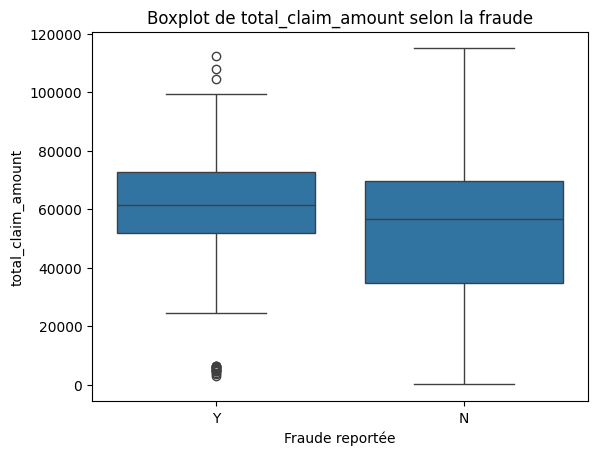

In [90]:

# Exemple d'utilisation
check_outlier_rows(df, 'total_claim_amount')

**#Property claim:**  
y a seulemnt 6 valeurs abbérantes qui sont toutes des "major damage"

Statistiques pour vehicle_claim (fraude = Y) :
count      247.000000
mean     43533.643725
std      14849.388907
min       2080.000000
25%      37170.000000
50%      44800.000000
75%      52080.000000
max      77760.000000
Name: vehicle_claim, dtype: float64 

Nombre total d'outliers: 20

Exemple de table des outliers :


,months_as_customer,age,policy_number,policy_bind_date,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,insured_sex,insured_education_level,insured_occupation,insured_hobbies,insured_relationship,capital-gains,capital-loss,incident_date,incident_type,collision_type,incident_severity,authorities_contacted,incident_state,incident_city,incident_location,incident_hour_of_the_day,number_of_vehicles_involved,property_damage,bodily_injuries,witnesses,police_report_available,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_make,auto_model,auto_year,fraud_reported
1,228,42,342868,2006-06-27,IN,250/500,2000,1197.22,5000000,468176,MALE,MD,machine-op-inspct,reading,other-relative,0,0,2015-01-21,Vehicle Theft,?,Minor Damage,Police,VA,Riverwood,6608 MLK Hwy,8,1,?,0,0,?,5070,780,780,3510,Mercedes,E400,2007,Y
27,202,34,608513,2002-07-18,IN,100/300,500,848.07,3000000,607730,MALE,JD,exec-managerial,chess,not-in-family,31000,-30200,2015-01-07,Vehicle Theft,?,Minor Damage,NaN,VA,Northbrook,3790 Andromedia Hwy,5,1,YES,2,1,?,5720,1040,520,4160,Suburu,Forrestor,2003,Y
145,398,58,515050,2000-11-16,OH,100/300,500,990.98,0,469429,FEMALE,Associate,exec-managerial,cross-fit,wife,0,-57900,2015-02-02,Single Vehicle Collision,Front Collision,Major Damage,Police,NC,Northbrook,1536 Flute Drive,18,1,YES,2,1,?,99320,7640,15280,76400,Accura,TL,2002,Y
149,193,41,217938,1995-07-16,OH,250/500,500,847.03,0,438555,FEMALE,JD,craft-repair,skydiving,not-in-family,0,0,2015-02-08,Single Vehicle Collision,Side Collision,Major Damage,Other,SC,Springfield,5431 3rd Ridge,1,1,?,1,0,YES,112320,17280,17280,77760,Suburu,Impreza,2011,Y
163,112,30,346940,2002-09-13,OH,500/1000,1000,1166.54,0,479852,FEMALE,Masters,prof-specialty,sleeping,not-in-family,47700,-59300,2015-01-21,Single Vehicle Collision,Front Collision,Major Damage,Fire,SC,Arlington,9316 Pine Ave,3,1,YES,2,0,NO,107900,10790,21580,75530,Dodge,Neon,1997,Y
196,196,36,602410,1996-01-16,IN,250/500,2000,1463.07,0,615611,MALE,MD,armed-forces,skydiving,own-child,0,0,2015-01-24,Vehicle Theft,?,Trivial Damage,Police,WV,Springfield,4939 Best St,3,1,?,1,1,NO,5300,530,530,4240,Jeep,Grand Cherokee,2001,Y
281,186,33,779075,2010-02-27,IN,100/300,1000,1348.32,0,469429,FEMALE,Associate,craft-repair,cross-fit,wife,37600,-37600,2015-01-14,Vehicle Theft,?,Trivial Damage,Police,NY,Arlington,8477 Francis Hwy,3,1,NO,2,1,?,4730,860,860,3010,Chevrolet,Malibu,2013,Y
364,291,46,832746,2006-04-13,OH,500/1000,1000,994.74,0,452701,FEMALE,High School,adm-clerical,polo,own-child,0,-55300,2015-01-25,Parked Car,?,Minor Damage,Police,SC,Hillsdale,1919 4th Lane,8,1,NO,2,2,YES,5580,620,620,4340,Volkswagen,Passat,2005,Y
365,162,31,386690,2006-02-21,IN,100/300,1000,1050.24,0,456789,FEMALE,Masters,adm-clerical,chess,wife,30700,0,2015-02-26,Parked Car,?,Minor Damage,NaN,NC,Arlington,5480 3rd Ridge,7,1,?,0,0,NO,3600,360,720,2520,BMW,X5,2013,Y
373,140,31,388671,1997-05-01,OH,250/500,2000,1554.86,6000000,608758,FEMALE,JD,armed-forces,base-jumping,wife,59000,0,2015-02-16,Parked Car,?,Minor Damage,NaN,WV,Arlington,4585 Francis Ave,2,1,YES,1,2,?,6120,680,680,4760,Honda,Civic,2002,Y


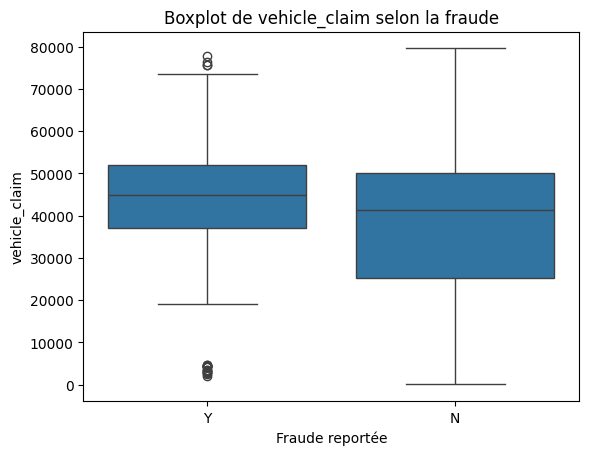

In [91]:

check_outlier_rows(df,'vehicle_claim')

In [92]:
check_outlier_rows('vehicle_claim')

TypeError: check_outlier_rows() missing 1 required positional argument: 'variable'

**col with outlier**
- age(same distribution between Fraud and non fraud)   
- policy annual premium (same distribution between Fraud and non fraud) : (= montant payé par l’assuré à la compagnie d’assurance)   
- ***total claim amount  (outlier only with non Fraud)***   
- ***property claim***   
- ***vehicle claim (outlier only with non Fraud)***   

## Numerical - Correlation

# Categorical Variables


    

In [94]:
#Variable catégorielle
cat_cols = df.select_dtypes(include='object').columns.tolist()
print(cat_cols)
len(cat_cols)



['policy_state', 'policy_csl', 'insured_sex', 'insured_education_level', 'insured_occupation', 'insured_hobbies', 'insured_relationship', 'incident_type', 'collision_type', 'incident_severity', 'authorities_contacted', 'incident_state', 'incident_city', 'incident_location', 'property_damage', 'police_report_available', 'auto_make', 'auto_model', 'fraud_reported']


C:\Users\rvoul\AppData\Local\Temp\ipykernel_30308\3612106178.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns.tolist()


19

In [102]:
import math
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Grille 3 x 7 (comme dans ton code)
n_rows = 3
n_cols = 7

# Création des sous-graphes pour les variables catégorielles
fig = make_subplots(
    rows=n_rows,
    cols=n_cols,
    subplot_titles=cat_cols  # titres des subplots
)

row = 1
col_pos = 1
color_map = {
    'N': "blue",
    'Y': "red"}

for col in cat_cols:
    # Tableau croisé + pourcentage
    ct = pd.crosstab(df[col], df['fraud_reported'], normalize='index') * 100
    
    for fraud_value in ct.columns:
        fig.add_trace(
            go.Bar(
                x=ct.index,
                y=ct[fraud_value],
                name=str(fraud_value),
                marker_color=color_map[fraud_value],  # équivalent de 'hue' en Plotly
                showlegend=(row == 1 and col_pos == 1),  # légende affichée une seule fois
            ),
            row=row,
            col=col_pos
        )
    
    # Rotation des labels X
    fig.update_xaxes(tickangle=45, row=row, col=col_pos)
    
    # Passage au subplot suivant
    col_pos += 1
    if col_pos > n_cols:
        col_pos = 1
        row += 1

# Layout global
fig.update_layout(
    height=900,
    width=1600,
    title_text="Variables catégorielles vs Fraude (%)",
    title_font_size=24,
    barmode="group"
)

fig.show()

# Optionnel : sauvegarder l'image
# fig.write_image(
#     r'C:\Users\rvoul\Documents\formation_data_scientist\projet_fil_rouge\rapport\variable_cat_plotly.png',
#     width=3200,
#     height=1800,
#     scale=3
# )

## Categorical - Correlation

In [ ]:
df["policy_bind_date"] = pd.to_datetime(df["policy_bind_date"])
df["incident_date"] = pd.to_datetime(df["incident_date"])

In [ ]:
list(df.select_dtypes(include='O').columns)

['policy_state',
 'policy_csl',
 'insured_sex',
 'insured_education_level',
 'insured_occupation',
 'insured_hobbies',
 'insured_relationship',
 'incident_type',
 'collision_type',
 'incident_severity',
 'authorities_contacted',
 'incident_state',
 'incident_city',
 'incident_location',
 'property_damage',
 'police_report_available',
 'auto_make',
 'auto_model',
 'fraud_reported']

In [ ]:
df_encoded = pd.get_dummies(df, columns=list(df.select_dtypes(include='O').columns))
print(df_encoded.shape)
df_encoded.head(5)

(1000, 1167)


,months_as_customer,age,policy_number,policy_bind_date,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,capital-gains,capital-loss,incident_date,incident_hour_of_the_day,number_of_vehicles_involved,bodily_injuries,witnesses,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_year,_c39,policy_state_IL,policy_state_IN,policy_state_OH,policy_csl_100/300,policy_csl_250/500,policy_csl_500/1000,insured_sex_FEMALE,insured_sex_MALE,insured_education_level_Associate,insured_education_level_College,insured_education_level_High School,insured_education_level_JD,insured_education_level_MD,insured_education_level_Masters,insured_education_level_PhD,insured_occupation_adm-clerical,insured_occupation_armed-forces,insured_occupation_craft-repair,insured_occupation_exec-managerial,insured_occupation_farming-fishing,insured_occupation_handlers-cleaners,insured_occupation_machine-op-inspct,insured_occupation_other-service,insured_occupation_priv-house-serv,insured_occupation_prof-specialty,insured_occupation_protective-serv,insured_occupation_sales,insured_occupation_tech-support,insured_occupation_transport-moving,insured_hobbies_base-jumping,insured_hobbies_basketball,insured_hobbies_board-games,insured_hobbies_bungie-jumping,insured_hobbies_camping,insured_hobbies_chess,insured_hobbies_cross-fit,insured_hobbies_dancing,insured_hobbies_exercise,insured_hobbies_golf,insured_hobbies_hiking,insured_hobbies_kayaking,insured_hobbies_movies,insured_hobbies_paintball,insured_hobbies_polo,insured_hobbies_reading,insured_hobbies_skydiving,insured_hobbies_sleeping,insured_hobbies_video-games,insured_hobbies_yachting,insured_relationship_husband,insured_relationship_not-in-family,insured_relationship_other-relative,insured_relationship_own-child,insured_relationship_unmarried,insured_relationship_wife,incident_type_Multi-vehicle Collision,incident_type_Parked Car,incident_type_Single Vehicle Collision,incident_type_Vehicle Theft,collision_type_?,collision_type_Front Collision,collision_type_Rear Collision,collision_type_Side Collision,incident_severity_Major Damage,incident_severity_Minor Damage,incident_severity_Total Loss,incident_severity_Trivial Damage,authorities_contacted_Ambulance,authorities_contacted_Fire,authorities_contacted_Other,authorities_contacted_Police,incident_state_NC,incident_state_NY,incident_state_OH,incident_state_PA,incident_state_SC,incident_state_VA,incident_state_WV,incident_city_Arlington,incident_city_Columbus,incident_city_Hillsdale,incident_city_Northbend,incident_city_Northbrook,incident_city_Riverwood,incident_city_Springfield,incident_location_1012 5th Lane,incident_location_1028 Sky Lane,incident_location_1030 Pine Lane,incident_location_1087 Flute Drive,incident_location_1091 1st Drive,incident_location_1102 Apache Hwy,incident_location_1110 4th Drive,incident_location_1123 5th Lane,incident_location_1126 Texas Hwy,incident_location_1128 Maple Lane,incident_location_1133 Apache St,incident_location_1135 Solo Lane,incident_location_1173 Andromedia Ave,incident_location_1186 Rock St,incident_location_1213 4th Lane,incident_location_1215 Pine Hwy,incident_location_1218 Sky Hwy,incident_location_1220 MLK Ave,incident_location_1229 5th Ave,incident_location_1240 Tree Lane,incident_location_1248 MLK Ridge,incident_location_1267 Francis Hwy,incident_location_1269 Flute Drive,incident_location_1273 Rock Lane,incident_location_1275 4th Ridge,incident_location_1298 Maple Hwy,incident_location_1306 Andromedia St,incident_location_1316 Britain Ridge,incident_location_1320 Flute Lane,incident_location_1325 1st Lane,incident_location_1328 Texas Lane,incident_location_1331 Britain Hwy,incident_location_1331 Elm Ridge,incident_location_1346 5th Lane,incident_location_1353 Washington St,incident_location_1358 Maple St,incident_location_1364 Best St,incident_location_1365 Francis Ave,incident_location_1371 Texas Lane,incident_location_1376 Pine St,incident_location_1381 Francis Ave,incident_location_1386

In [ ]:
df_encoded.columns

Index(['months_as_customer', 'age', 'policy_number', 'policy_bind_date',
       'policy_deductable', 'policy_annual_premium', 'umbrella_limit',
       'insured_zip', 'capital-gains', 'capital-loss',
       ...
       'auto_model_Pathfinder', 'auto_model_RAM', 'auto_model_RSX',
       'auto_model_Silverado', 'auto_model_TL', 'auto_model_Tahoe',
       'auto_model_Ultima', 'auto_model_Wrangler', 'auto_model_X5',
       'auto_model_X6'],
      dtype='object', length=166)

In [ ]:
cat_var1_df = df_encoded.select_dtypes(include='bool').drop(columns=['fraud_reported_N','insured_sex_MALE'], axis = 1)
cat_var1 = cat_var1_df.columns
cat_var1

Index(['fraud_reported_Y', 'policy_state_IL', 'policy_state_IN',
       'policy_state_OH', 'policy_csl_100/300', 'policy_csl_250/500',
       'policy_csl_500/1000', 'insured_sex_FEMALE',
       'insured_education_level_Associate', 'insured_education_level_College',
       ...
       'auto_model_Pathfinder', 'auto_model_RAM', 'auto_model_RSX',
       'auto_model_Silverado', 'auto_model_TL', 'auto_model_Tahoe',
       'auto_model_Ultima', 'auto_model_Wrangler', 'auto_model_X5',
       'auto_model_X6'],
      dtype='object', length=141)

In [ ]:
from itertools import combinations
from scipy.stats import chi2_contingency
import pandas as pd

df_cat_v1 = df_encoded[list(cat_var1)]

result = []

for var1, var2 in combinations(cat_var1, 2):
    ct = pd.crosstab(df_cat_v1[var1], df_cat_v1[var2])
    chi2, p, dof, expected = chi2_contingency(ct)
    result.append((var1, var2, p))

result


[('fraud_reported_Y', 'policy_state_IL', np.float64(0.35345697471253945)),
 ('fraud_reported_Y', 'policy_state_IN', np.float64(0.7596129472225719)),
 ('fraud_reported_Y', 'policy_state_OH', np.float64(0.5850967793876896)),
 ('fraud_reported_Y', 'policy_csl_100/300', np.float64(0.6120222544603281)),
 ('fraud_reported_Y', 'policy_csl_250/500', np.float64(0.4605822353025225)),
 ('fraud_reported_Y', 'policy_csl_500/1000', np.float64(0.16879769431670572)),
 ('fraud_reported_Y', 'insured_sex_FEMALE', np.float64(0.36665138406877407)),
 ('fraud_reported_Y',
  'insured_education_level_Associate',
  np.float64(0.7841999049232519)),
 ('fraud_reported_Y',
  'insured_education_level_College',
  np.float64(0.7595745294276954)),
 ('fraud_reported_Y',
  'insured_education_level_High School',
  np.float64(0.54582107563771)),
 ('fraud_reported_Y',
  'insured_education_level_JD',
  np.float64(0.7295327041435756)),
 ('fraud_reported_Y',
  'insured_education_level_MD',
  np.float64(0.6865807833114993)),
 (

In [ ]:
df_results = pd.DataFrame(result)
df_results = df_results[df_results[0]=='fraud_reported_Y'].sort_values([2], ascending=[True])
df_results.head(10)

,0,1,2
62,fraud_reported_Y,incident_severity_Major Damage,1.595859e-58
33,fraud_reported_Y,insured_hobbies_chess,5.746682e-20
63,fraud_reported_Y,incident_severity_Minor Damage,6.198478e-14
34,fraud_reported_Y,insured_hobbies_cross-fit,1.757265e-11
64,fraud_reported_Y,incident_severity_Total Loss,9.625512e-08
58,fraud_reported_Y,collision_type_?,1.401416e-07
65,fraud_reported_Y,incident_severity_Trivial Damage,5.569816e-05
57,fraud_reported_Y,incident_type_Vehicle Theft,2.172473e-04
55,fraud_reported_Y,incident_type_Parked Car,1.205125e-03
60,fraud_reported_Y,collision_type_Rear Collision,3.042158e-03


## Categorical - Plots

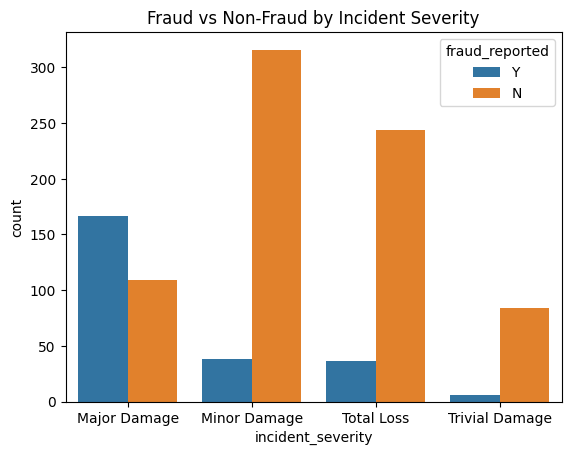

In [ ]:
sns.countplot(x = 'incident_severity', hue = 'fraud_reported', data = df)
plt.title("Fraud vs Non-Fraud by Incident Severity")
plt.show()

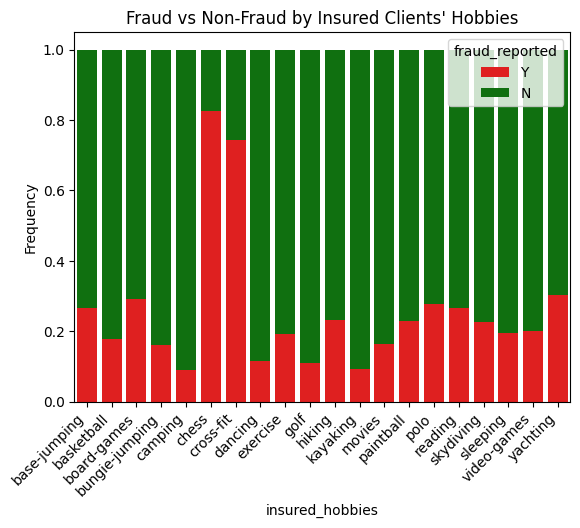

In [ ]:
ct = pd.crosstab(df['insured_hobbies'], df['fraud_reported'], normalize='index')
ct = ct[['Y', 'N']]   # Swaps position

ct_long = ct.reset_index().melt(id_vars='insured_hobbies',var_name='fraud_reported',value_name='count')

# Create base plot
fig, ax = plt.subplots()

# Plot Yes first
sns.barplot(data=ct_long[ct_long['fraud_reported'] == 'Y'],
            x='insured_hobbies',y='count', color='red',label='Y',ax=ax)

# Plot No stacked on top
bottom_vals = ct['Y'].values

sns.barplot(data=ct_long[ct_long['fraud_reported'] == 'N'], 
            x='insured_hobbies',y='count', color='green',label='N',ax=ax,bottom=bottom_vals)

plt.ylabel('Frequency')
plt.title("Fraud vs Non-Fraud by Insured Clients' Hobbies")
plt.legend(title='fraud_reported')
plt.xticks(rotation=45, ha='right')
plt.show()

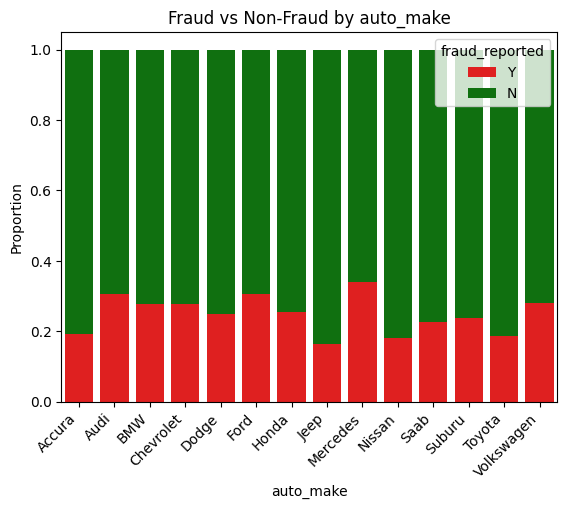

In [ ]:
ct = pd.crosstab(df['auto_make'], df['fraud_reported'], normalize='index') 
ct = ct[['Y', 'N']] # Swaps position 
ct_long = ct.reset_index().melt(id_vars='auto_make',var_name='fraud_reported',value_name='count') 
# Create base plot 
fig, ax = plt.subplots() 
# Plot Yes first 
sns.barplot(data=ct_long[ct_long['fraud_reported'] == 'Y'], x='auto_make',y='count', color='red',label='Y',ax=ax) 
# Plot No stacked on top 
bottom_vals = ct['Y'].values 
sns.barplot(data=ct_long[ct_long['fraud_reported'] == 'N'], x='auto_make',y='count', color='green',label='N',ax=ax,bottom=bottom_vals) 
plt.ylabel('Proportion') 
plt.title("Fraud vs Non-Fraud by auto_make") 
plt.legend(title='fraud_reported') 
plt.xticks(rotation=45, ha='right') 
plt.show()

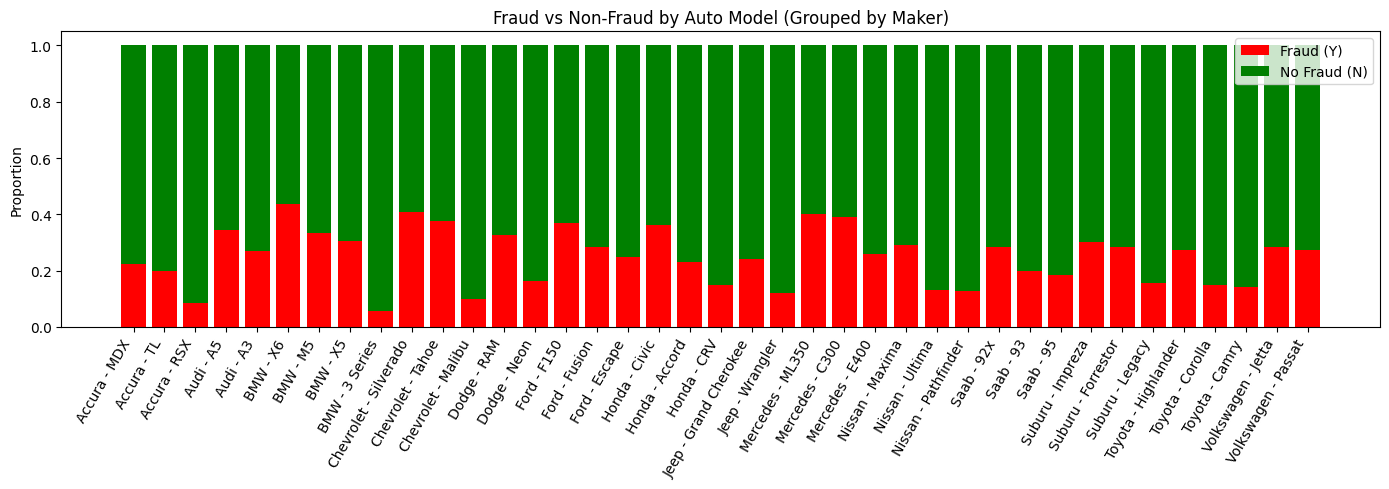

In [ ]:
# Crosstab normalized by model within maker 
ct = pd.crosstab([df['auto_make'], df['auto_model']], df['fraud_reported'], normalize='index')
ct = ct[['Y', 'N']]   # order Y then N

# Sort models inside each maker by fraud rate
ct = ct.sort_values(by=['auto_make', 'Y'], ascending=[True, False])

# Create labels "Maker - Model"
labels = [f"{make} - {model}" for make, model in ct.index]

# Plot stacked bars
plt.figure(figsize=(14, 5))

plt.bar(labels, ct['Y'], color='red', label='Fraud (Y)')
plt.bar(labels, ct['N'], bottom=ct['Y'], color='green', label='No Fraud (N)')

plt.ylabel("Proportion")
plt.title("Fraud vs Non-Fraud by Auto Model (Grouped by Maker)")
plt.xticks(rotation=60, ha='right')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
# Create normalized crosstab

females = df[df['insured_sex']=='FEMALE']

ct = pd.crosstab(females['auto_model'],females['fraud_reported'],normalize='index')
ct = ct[['Y', 'N']]
top5_models_female = ct.sort_values(by='Y', ascending=False).head(5)

top5_models_female_list = top5_models_female.index.tolist()
top5_models_female_df = df[df['auto_model'].isin(top5_models_female_list)]
top5_models_female

fraud_reported,Y,N
auto_model,,
X6,0.500000,0.500000
Tahoe,0.500000,0.500000
Silverado,0.500000,0.500000
Civic,0.444444,0.555556
ML350,0.444444,0.555556


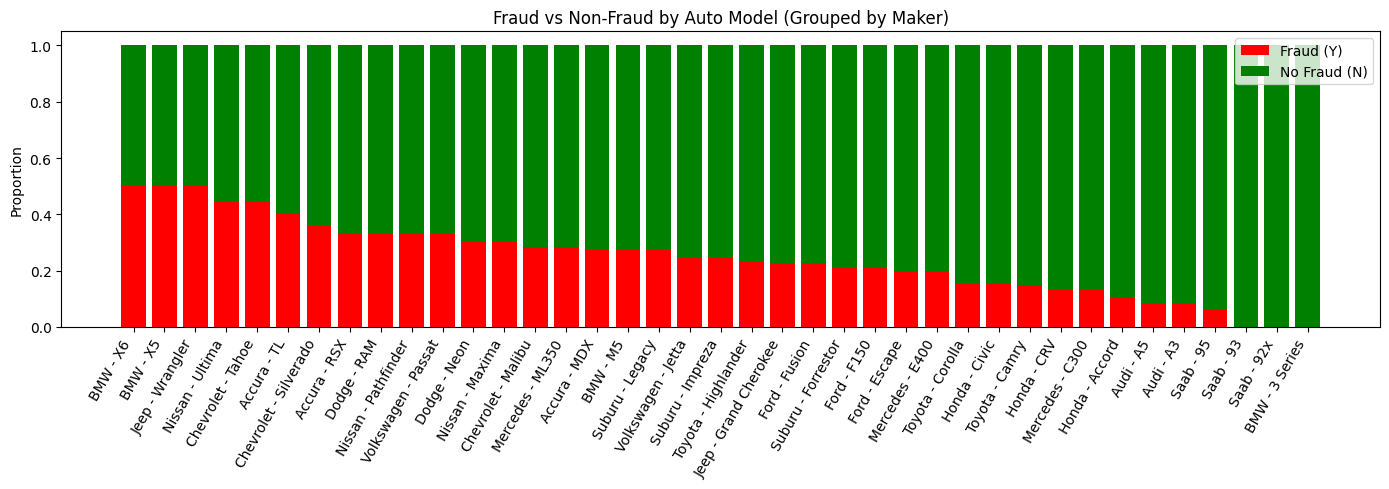

In [ ]:
females = df[df['insured_sex']=='FEMALE']

# Crosstab normalized by model within maker 
ct = pd.crosstab(females['auto_model'], females['fraud_reported'], normalize='index')
ct = ct[['Y', 'N']]   # order Y then N

# Sort models inside each maker by fraud rate
ct = ct.sort_values(by='Y', ascending=False)

# Create labels "Maker - Model"
#labels = [f"{make} - {model}" for make, model in ct.index]

# Plot stacked bars
plt.figure(figsize=(14, 5))

plt.bar(labels, ct['Y'], color='red', label='Fraud (Y)')
plt.bar(labels, ct['N'], bottom=ct['Y'], color='green', label='No Fraud (N)')

plt.ylabel("Proportion")
plt.title("Fraud vs Non-Fraud by Auto Model (Grouped by Maker)")
plt.xticks(rotation=60, ha='right')
plt.legend()

plt.tight_layout()
plt.show()

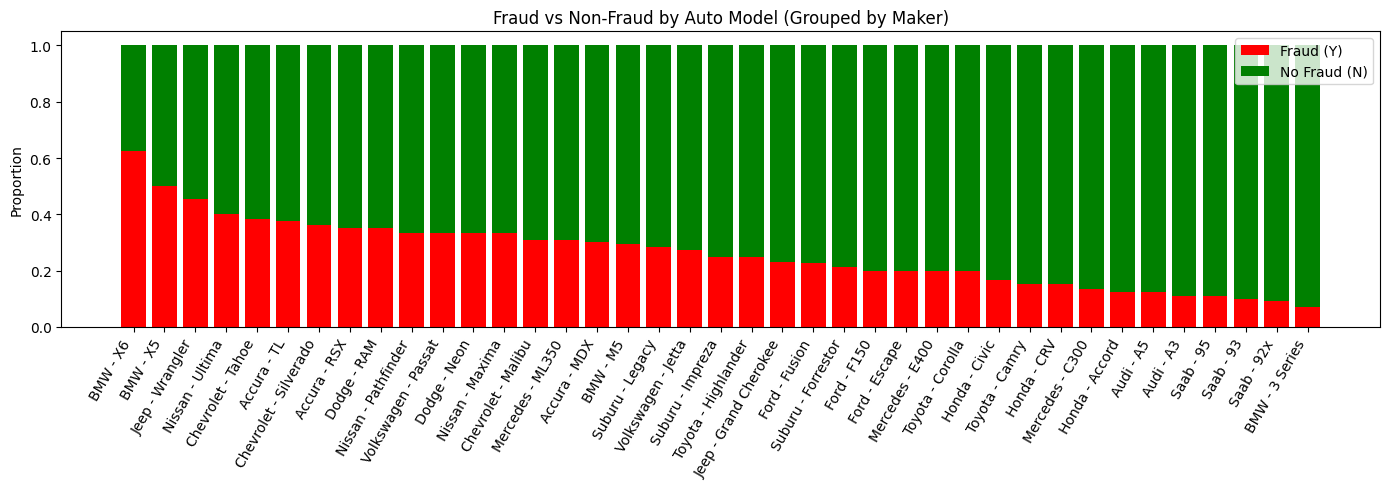

In [ ]:
males = df[df['insured_sex']=='MALE']

# Crosstab normalized by model within maker 
ct = pd.crosstab(males['auto_model'], males['fraud_reported'], normalize='index')
ct = ct[['Y', 'N']]   # order Y then N

# Sort models inside each maker by fraud rate
ct = ct.sort_values(by='Y', ascending=False)

# Create labels "Maker - Model"
#labels = [f"{make} - {model}" for make, model in ct.index]

# Plot stacked bars
plt.figure(figsize=(14, 5))

plt.bar(labels, ct['Y'], color='red', label='Fraud (Y)')
plt.bar(labels, ct['N'], bottom=ct['Y'], color='green', label='No Fraud (N)')

plt.ylabel("Proportion")
plt.title("Fraud vs Non-Fraud by Auto Model (Grouped by Maker)")
plt.xticks(rotation=60, ha='right')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
df.columns

Index(['months_as_customer', 'age', 'policy_number', 'policy_bind_date',
       'policy_state', 'policy_csl', 'policy_deductable',
       'policy_annual_premium', 'umbrella_limit', 'insured_zip', 'insured_sex',
       'insured_education_level', 'insured_occupation', 'insured_hobbies',
       'insured_relationship', 'capital-gains', 'capital-loss',
       'incident_date', 'incident_type', 'collision_type', 'incident_severity',
       'authorities_contacted', 'incident_state', 'incident_city',
       'incident_location', 'incident_hour_of_the_day',
       'number_of_vehicles_involved', 'property_damage', 'bodily_injuries',
       'witnesses', 'police_report_available', 'total_claim_amount',
       'injury_claim', 'property_claim', 'vehicle_claim', 'auto_make',
       'auto_model', 'auto_year', 'fraud_reported', '_c39'],
      dtype='object')

In [ ]:
# 'incident_type', 'collision_type', 'incident_severity', 
# 'authorities_contacted', 'witnesses', 'police_report_available'
# 'incident_hour_of_the_day'
# 'number_of_vehicles_involved', 'property_damage', 'bodily_injuries', 
# 'total_claim_amount'
# 'injury_claim', 'property_claim', 'vehicle_claim', 
# 'auto_make', 'auto_model', 'auto_year'
# 'policy_state', 'policy_csl'
# 'policy_bind_date'
# 'insured_sex'

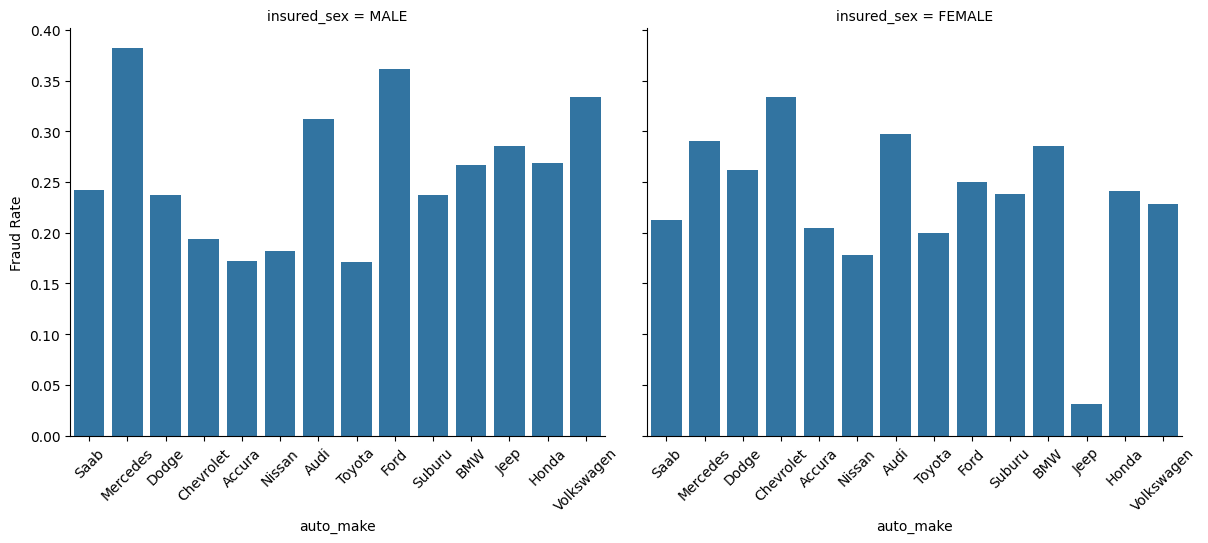

In [ ]:
g = sns.catplot(
    data=df,
    x='auto_make',
    y=(df['fraud_reported'] == 'Y'),
    col='insured_sex',
    kind='bar',
    height=5,
    aspect=1.2,
    errorbar=None
)

g.set_xticklabels(rotation=45)
g.set_ylabels("Fraud Rate");

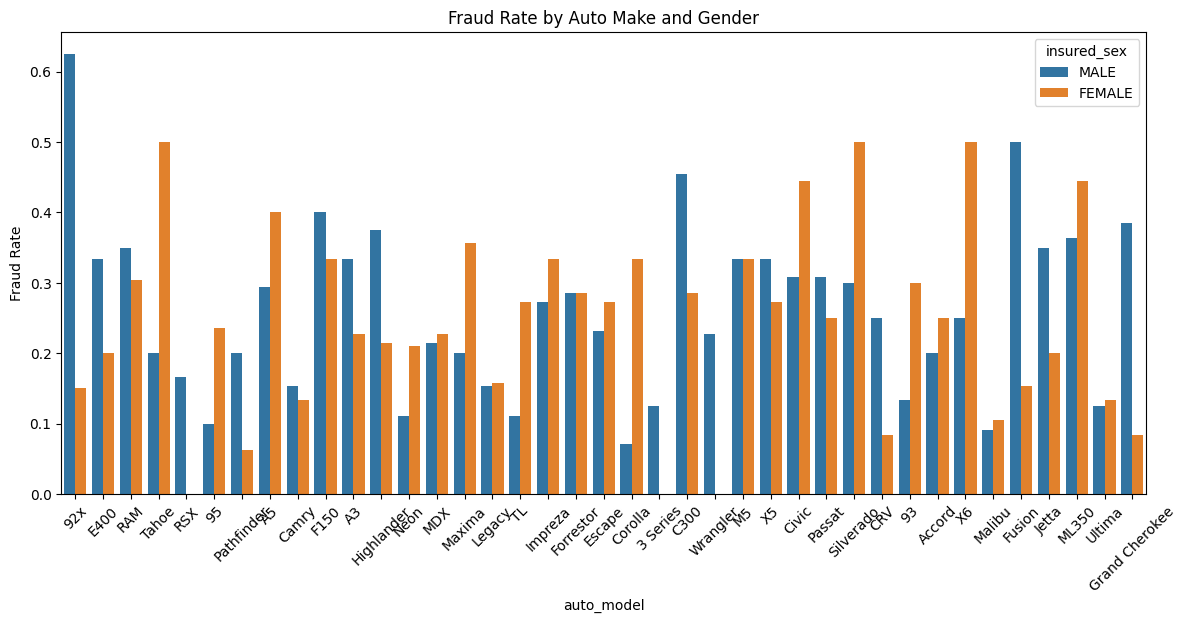

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

sns.barplot(
    data=df,
    x='auto_model',
    y=(df['fraud_reported'] == 'Y'),
    hue='insured_sex',
    errorbar=None
)

plt.title("Fraud Rate by Auto Make and Gender")
plt.ylabel("Fraud Rate")
plt.xticks(rotation=45)
plt.show()

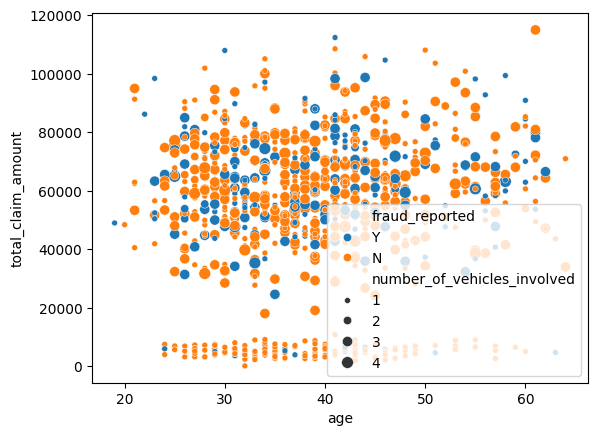

In [ ]:
sns.scatterplot(
    data=df,
    x='age',
    y='total_claim_amount',
    hue='fraud_reported',
    size='number_of_vehicles_involved'
);

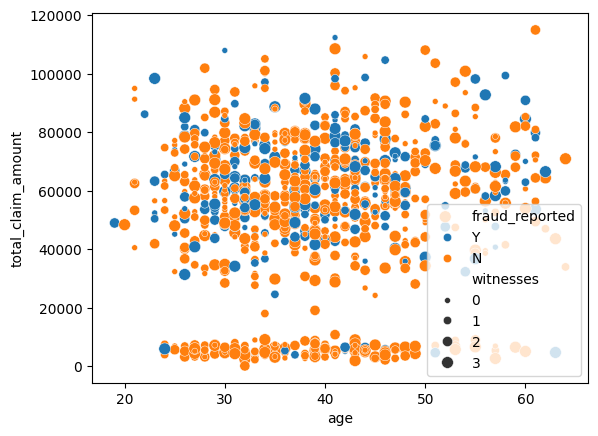

In [ ]:
sns.scatterplot(
    data=df,
    x='age',
    y='total_claim_amount',
    hue='fraud_reported',
    size='witnesses'
);

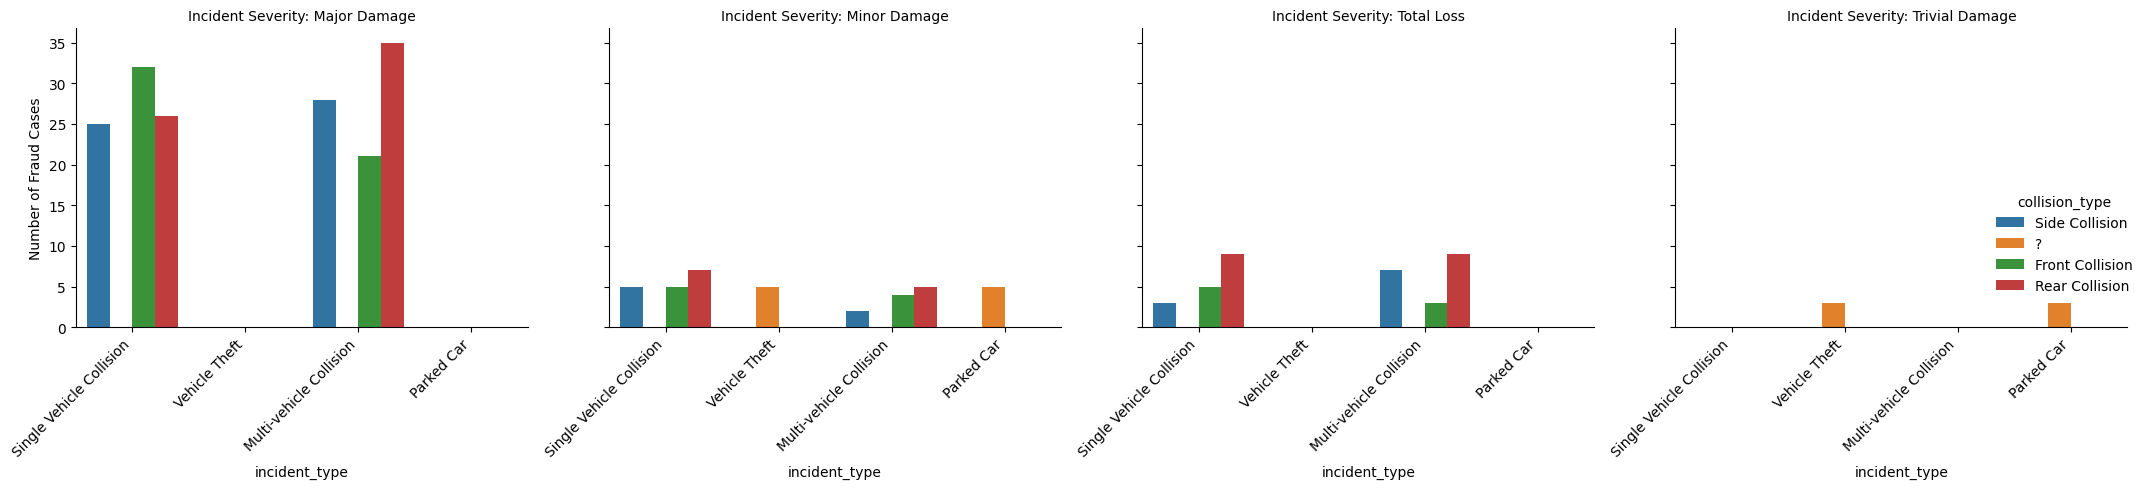

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Filter only fraud cases
g = sns.catplot(
    data=df[df['fraud_reported']=='Y'],
    x='incident_type',
    hue='collision_type',
    col='incident_severity',
    kind='count',
    height=5,
    aspect=1
)

# Rotate x-axis labels for all facets
g.set_xticklabels(rotation=45, horizontalalignment='right')

# Set y-labels and titles
g.set_ylabels("Number of Fraud Cases")
g.set_titles("Incident Severity: {col_name}")

plt.tight_layout()
plt.show()

In [ ]:
frauds = df[df['fraud_reported']=='Y']
f = frauds[frauds['incident_severity']=='Trivial Damage']
f

,months_as_customer,age,policy_number,policy_bind_date,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,insured_sex,insured_education_level,insured_occupation,insured_hobbies,insured_relationship,capital-gains,capital-loss,incident_date,incident_type,collision_type,incident_severity,authorities_contacted,incident_state,incident_city,incident_location,incident_hour_of_the_day,number_of_vehicles_involved,property_damage,bodily_injuries,witnesses,police_report_available,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_make,auto_model,auto_year,fraud_reported,_c39
196,196,36,602410,1996-01-16,IN,250/500,2000,1463.07,0,615611,MALE,MD,armed-forces,skydiving,own-child,0,0,2015-01-24,Vehicle Theft,?,Trivial Damage,Police,WV,Springfield,4939 Best St,3,1,?,1,1,NO,5300,530,530,4240,Jeep,Grand Cherokee,2001,Y,NaN
281,186,33,779075,2010-02-27,IN,100/300,1000,1348.32,0,469429,FEMALE,Associate,craft-repair,cross-fit,wife,37600,-37600,2015-01-14,Vehicle Theft,?,Trivial Damage,Police,NY,Arlington,8477 Francis Hwy,3,1,NO,2,1,?,4730,860,860,3010,Chevrolet,Malibu,2013,Y,NaN
437,255,44,903203,2004-01-03,OH,500/1000,2000,814.96,6000000,435267,FEMALE,PhD,priv-house-serv,chess,not-in-family,68500,0,2015-02-05,Parked Car,?,Trivial Damage,Police,NC,Hillsdale,2787 MLK St,7,1,?,2,2,NO,6400,640,1280,4480,Mercedes,ML350,2005,Y,NaN
597,3,29,276804,1992-11-27,IL,100/300,500,995.70,5000000,615446,FEMALE,JD,priv-house-serv,chess,unmarried,0,0,2015-02-02,Parked Car,?,Trivial Damage,Police,PA,Springfield,1821 Andromedia Ridge,3,1,?,2,1,?,5000,500,1000,3500,Mercedes,E400,2008,Y,NaN
635,140,35,155912,2008-03-21,OH,100/300,1000,1520.78,0,470538,FEMALE,High School,craft-repair,chess,wife,0,-42900,2015-01-21,Parked Car,?,Trivial Damage,NaN,SC,Columbus,3320 5th Hwy,5,1,?,0,2,YES,2860,520,260,2080,Chevrolet,Tahoe,1997,Y,NaN
837,9,24,326180,2002-05-25,IL,100/300,2000,1304.46,0,473349,FEMALE,PhD,machine-op-inspct,golf,other-relative,51700,-33300,2015-01-31,Vehicle Theft,?,Trivial Damage,NaN,NC,Arlington,6939 3rd Hwy,6,1,NO,0,3,YES,5940,540,1080,4320,Audi,A5,2001,Y,NaN


In [ ]:
df.columns

Index(['months_as_customer', 'age', 'policy_number', 'policy_bind_date',
       'policy_state', 'policy_csl', 'policy_deductable',
       'policy_annual_premium', 'umbrella_limit', 'insured_zip', 'insured_sex',
       'insured_education_level', 'insured_occupation', 'insured_hobbies',
       'insured_relationship', 'capital-gains', 'capital-loss',
       'incident_date', 'incident_type', 'collision_type', 'incident_severity',
       'authorities_contacted', 'incident_state', 'incident_city',
       'incident_location', 'incident_hour_of_the_day',
       'number_of_vehicles_involved', 'property_damage', 'bodily_injuries',
       'witnesses', 'police_report_available', 'total_claim_amount',
       'injury_claim', 'property_claim', 'vehicle_claim', 'auto_make',
       'auto_model', 'auto_year', 'fraud_reported', '_c39'],
      dtype='object')

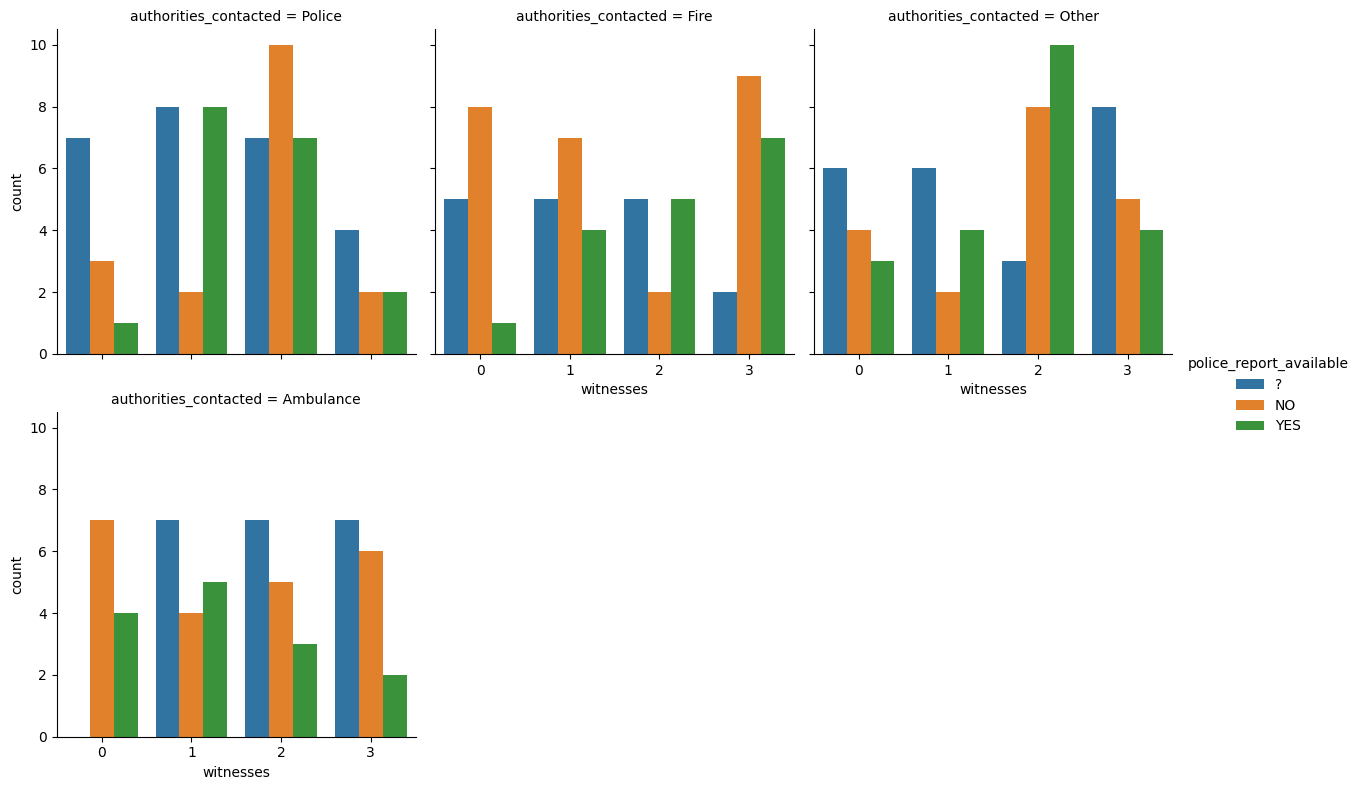

In [ ]:
sns.catplot(
    data=df[df['fraud_reported']=='Y'],  # only fraud cases
    x='witnesses',
    hue='police_report_available',
    col='authorities_contacted',
    kind='count',
    col_wrap=3,
    height=4,
    aspect=1
)

plt.xticks(rotation=0)
plt.show()